In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical

In [2]:
# Load LFW dataset

lfw = fetch_lfw_people(
    min_faces_per_person=70,
    resize=0.4
)

X = lfw.images
y = lfw.target
target_names = lfw.target_names

In [3]:
print("Image shape :", X.shape)
print("Labels shape:", y.shape)
print("Classes:", len(target_names))
print(target_names)

Image shape : (1288, 50, 37)
Labels shape: (1288,)
Classes: 7
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


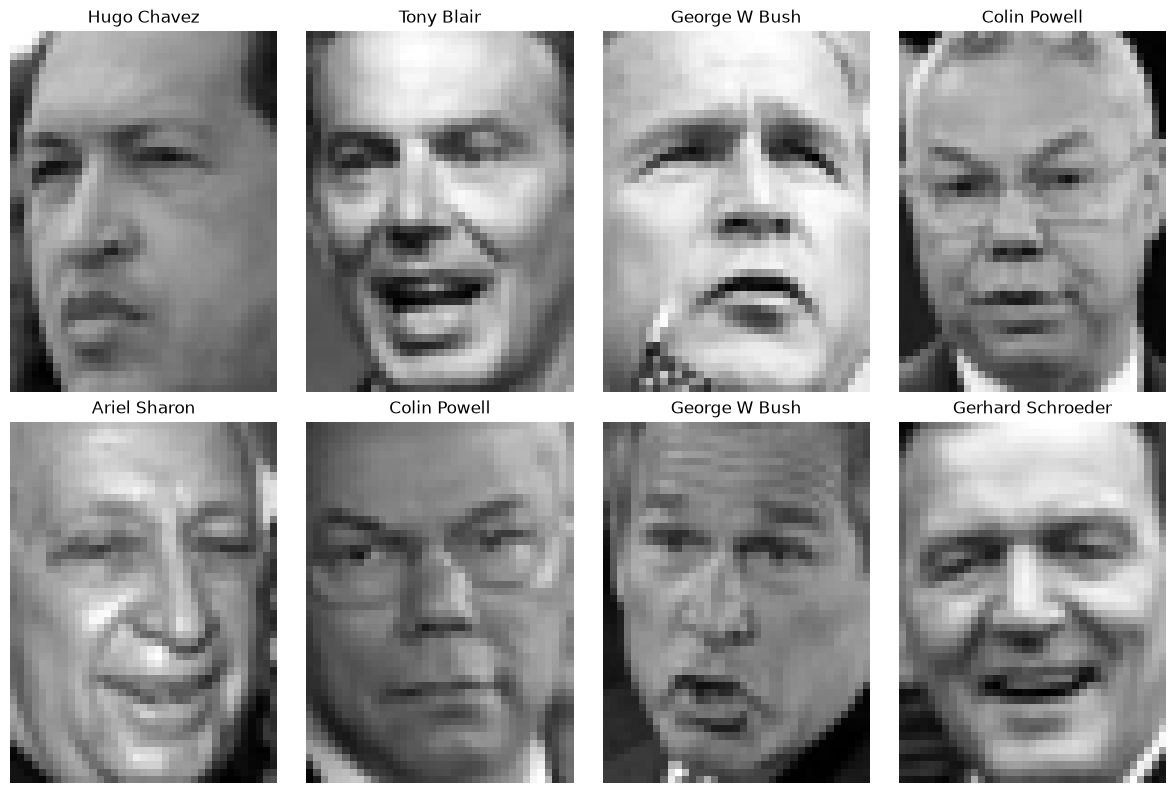

In [4]:
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(target_names[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
X = X / 255.0

In [6]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    X.shape[2],
    1
)

print(X.shape)

(1288, 50, 37, 1)


In [9]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    X.shape[2],
    1
)

print(X.shape)

(1288, 50, 37, 1)


In [10]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_encoded = to_categorical(y_encoded)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (1030, 50, 37, 1)
Testing samples : (258, 50, 37, 1)


In [12]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(y_train.shape[1], activation='softmax'))

model.summary()

c:\Users\shris\OneDrive\Desktop\Face-Recognition-CNN-LFW\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       630,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,631 (2.48 MB)

 Trainable params: 650,631 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3823 - loss: 1.8247 - val_accuracy: 0.4029 - val_loss: 1.7482
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3981 - loss: 1.7332 - val_accuracy: 0.4029 - val_loss: 1.6802
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3981 - loss: 1.7360 - val_accuracy: 0.4029 - val_loss: 1.6944
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3981 - loss: 1.7455 - val_accuracy: 0.4029 - val_loss: 1.6881
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3981 - loss: 1.7329 - val_accuracy: 0.4029 - val_loss: 1.6804
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3981 - loss: 1.7302 - val_accuracy: 0.4029 - val_loss: 1.6780
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3981 - loss: 1.7421 - val_accuracy: 0.4029 - val_loss: 1.6898
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3981 - loss: 1.7364 - val_accuracy: 0.4029 - v

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4612 - loss: 1.6070
Test Loss: 1.6070210933685303
Test Accuracy: 0.46124032139778137


In [18]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [19]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Prediction completed successfully!")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Prediction completed successfully!


In [20]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=target_names
))

                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        11
     Colin Powell       0.00      0.00      0.00        47
  Donald Rumsfeld       0.00      0.00      0.00        22
    George W Bush       0.46      1.00      0.63       119
Gerhard Schroeder       0.00      0.00      0.00        19
      Hugo Chavez       0.00      0.00      0.00        13
       Tony Blair       0.00      0.00      0.00        27

         accuracy                           0.46       258
        macro avg       0.07      0.14      0.09       258
     weighted avg       0.21      0.46      0.29       258



c:\Users\shris\OneDrive\Desktop\Face-Recognition-CNN-LFW\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shris\OneDrive\Desktop\Face-Recognition-CNN-LFW\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shris\OneDrive\Desktop\Face-Recognition-CNN-LFW\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [21]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [22]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=target_names
))

                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        11
     Colin Powell       0.00      0.00      0.00        47
  Donald Rumsfeld       0.00      0.00      0.00        22
    George W Bush       0.46      1.00      0.63       119
Gerhard Schroeder       0.00      0.00      0.00        19
      Hugo Chavez       0.00      0.00      0.00        13
       Tony Blair       0.00      0.00      0.00        27

         accuracy                           0.46       258
        macro avg       0.07      0.14      0.09       258
     weighted avg       0.21      0.46      0.29       258



c:\Users\shris\OneDrive\Desktop\Face-Recognition-CNN-LFW\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shris\OneDrive\Desktop\Face-Recognition-CNN-LFW\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shris\OneDrive\Desktop\Face-Recognition-CNN-LFW\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [23]:
cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[  0   0   0  11   0   0   0]
 [  0   0   0  47   0   0   0]
 [  0   0   0  22   0   0   0]
 [  0   0   0 119   0   0   0]
 [  0   0   0  19   0   0   0]
 [  0   0   0  13   0   0   0]
 [  0   0   0  27   0   0   0]]


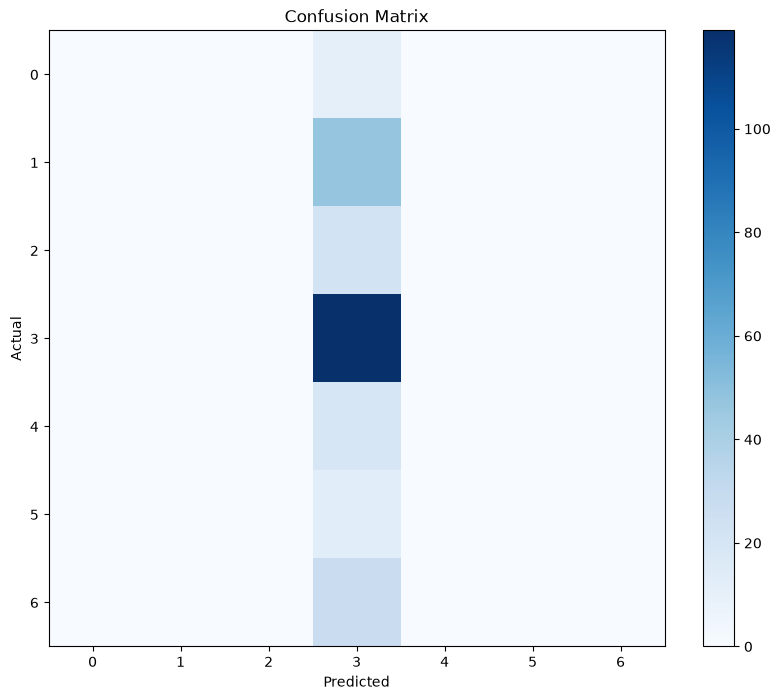

In [24]:
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

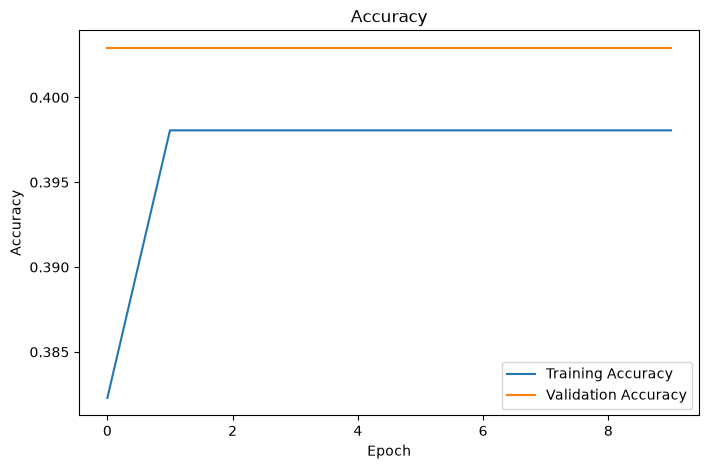

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [26]:
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/face_recognition_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


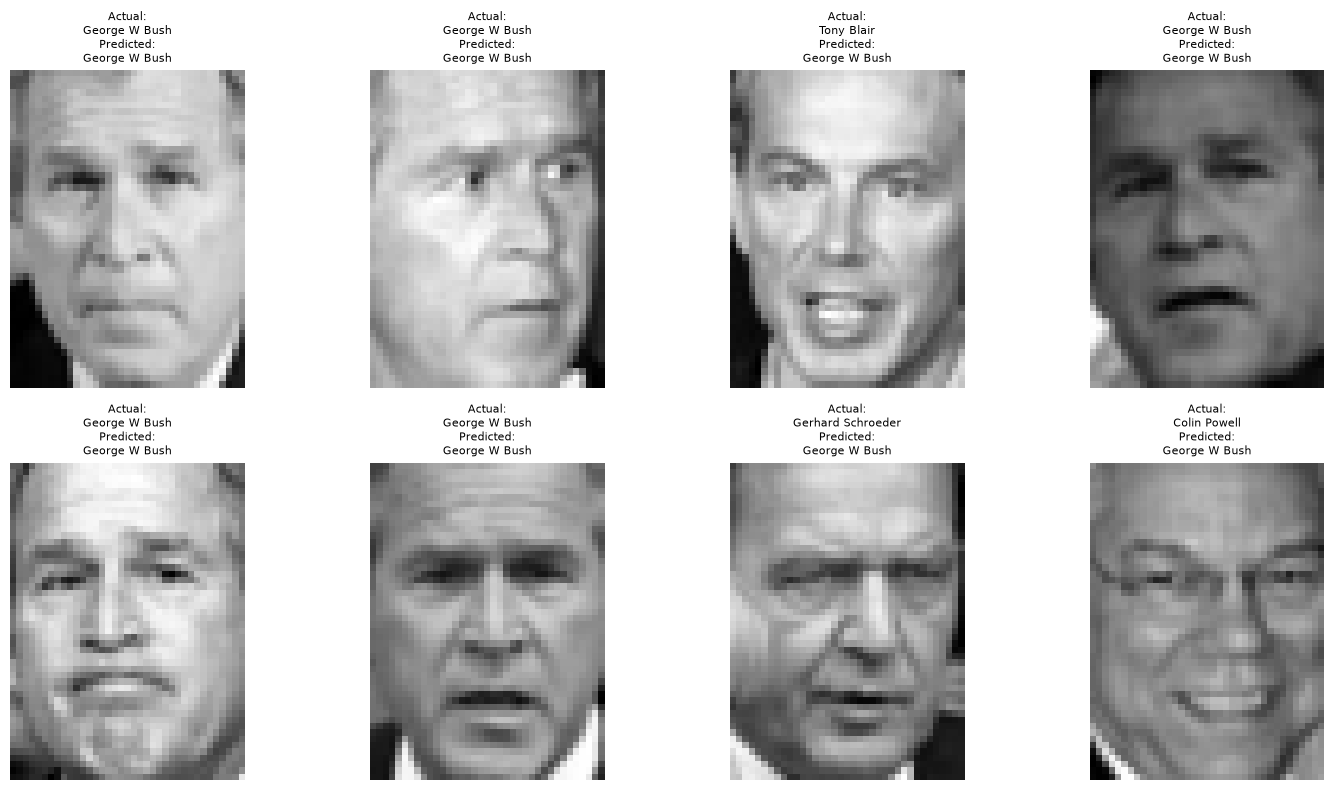

In [27]:
plt.figure(figsize=(15, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    plt.imshow(X_test[i].reshape(X_test.shape[1], X_test.shape[2]), cmap='gray')

    actual = target_names[y_true[i]]
    predicted = target_names[y_pred_classes[i]]

    plt.title(f"Actual:\n{actual}\nPredicted:\n{predicted}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

Final Test Accuracy: 46.12%
